## 1- GET DATA

Using National Basketball Association (NBA) team statistics from kaggle.

In [26]:
import pandas as pd

df = pd.read_csv("/content/nba_team_stats.csv")

pd.set_option('display.max_columns', None)
print(df.head())

      Season                   TEAM  GP    PTS   FGM   FGA   FG%   3PM   3PA  \
0  2022-2023       Sacramento Kings  82  120.7  43.6  88.2  49.4  13.8  37.3   
1  2022-2023  Golden State Warriors  82  118.9  43.1  90.2  47.9  16.6  43.2   
2  2022-2023          Atlanta Hawks  82  118.4  44.6  92.4  48.3  10.8  30.5   
3  2022-2023         Boston Celtics  82  117.9  42.2  88.8  47.5  16.0  42.6   
4  2022-2023  Oklahoma City Thunder  82  117.5  43.1  92.6  46.5  12.1  34.1   

    3P%   FTM   FTA   FT%    OR    DR   REB   AST  STL  BLK    TO    PF  
0  36.9  19.8  25.1  79.0   9.5  32.9  42.5  27.3  7.0  3.4  13.1  19.7  
1  38.5  16.0  20.2  79.4  10.5  34.1  44.6  29.8  7.2  4.0  15.7  21.4  
2  35.2  18.5  22.6  81.8  11.2  33.2  44.4  25.0  7.1  4.9  12.4  18.8  
3  37.7  17.5  21.6  81.2   9.7  35.6  45.3  26.7  6.4  5.2  12.7  18.8  
4  35.6  19.2  23.7  80.9  11.4  32.3  43.6  24.4  8.2  4.2  12.5  21.0  


## 2 - PREPROCESS (REMOVE NULLS 1/6)
There are no empty entries

In [27]:
print(df.isnull().sum().sum())

0


## 2 - PREPROCESS (ENCODE CATEGORICALS 2/6)
The dataset didn't have the winning teams, which is my desired target, so I added them manually. It's binary encoded on if the team won the championship.

In [28]:
CHAMPIONS = [
    ("2001-2002", "Los Angeles Lakers"),
    ("2002-2003", "San Antonio Spurs"),
    ("2003-2004", "Detroit Pistons"),
    ("2004-2005", "San Antonio Spurs"),
    ("2005-2006", "Miami Heat"),
    ("2006-2007", "San Antonio Spurs"),
    ("2007-2008", "Boston Celtics"),
    ("2008-2009", "Los Angeles Lakers"),
    ("2009-2010", "Los Angeles Lakers"),
    ("2010-2011", "Dallas Mavericks"),
    ("2011-2012", "Miami Heat"),
    ("2012-2013", "Miami Heat"),
    ("2013-2014", "San Antonio Spurs"),
    ("2014-2015", "Golden State Warriors"),
    ("2015-2016", "Cleveland Cavaliers"),
    ("2016-2017", "Golden State Warriors"),
    ("2017-2018", "Golden State Warriors"),
    ("2018-2019", "Toronto Raptors"),
    ("2019-2020", "Los Angeles Lakers"),
    ("2020-2021", "Milwaukee Bucks"),
    ("2021-2022", "Golden State Warriors"),
    ("2022-2023", "Denver Nuggets")
]

df["champion"] = df.apply(
    lambda x: 1 if (x["Season"], x["TEAM"]) in CHAMPIONS else 0,
    axis=1
)

## 2 - PREPROCESS (FEATURE ENGINEERING 3/6)
NBA stats averages changes throughout the years, so i took the diff from averages rather than absolute values.

In [29]:
stats_cols = df.select_dtypes(include=['float']).columns.values

def get_diff(row, col):
    szn = row["Season"]
    stats = df[df["Season"] == szn][col]
    avg = stats.mean()
    return row[col] - avg

for col in stats_cols:
    df[col+"_diff"] = df.apply(
        lambda x: get_diff(x, col),
        axis=1
    )

## 2 -  PREPROCESS (REMOVE DEAD COLS 4/6)
Some columns are useless now that some data been modified. Will remove because excessive information confuses model training

In [30]:
COLS_TO_REM = [
    "Season",
    "TEAM",
    "GP"
] + (stats_cols.tolist())

df.drop(COLS_TO_REM, axis=1, inplace=True)

## 2 - PREPROCESS (SCALE NUMERICALS 5/6)
### BUT SPLIT TRAIN/TEST FIRST
We will scale values because over-extreme ends can overshoot the model's interpretations. We will also scale the train and test differently which is why we should split it first.<br>
Below we can now see the values are machine friendly, centered around 0 and just simply numbers.<br>
The data is also imbalanced, most teams have not won the champsionship, so I'll proportionate the training and testing for both categories with stratify.

In [31]:
# SPLIT INTO TRAIN / TEST
from sklearn.model_selection import train_test_split

TARGET_COL = "champion"
SEED = 62

X = df.drop(columns=TARGET_COL)
y = df[TARGET_COL]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=SEED, stratify=y)

In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
print(X_val)

[[ 0.19303333 -0.12051372 -1.67805211 ...  1.99034712  0.78759301
  -1.00745304]
 [ 1.93415584  2.15616878  2.67804162 ...  1.47934752  0.76709024
   0.99390762]
 [ 1.62625434  1.24558592 -0.46270522 ...  0.58406148 -0.12025291
  -0.22375471]
 ...
 [-0.04168266  0.064878   -1.05353879 ...  0.67759883 -1.13435937
  -2.08692478]
 [ 0.70501964  0.79029449  1.04406171 ... -0.36912863 -0.37981587
  -1.49765445]
 [-1.88168226 -1.84560326 -1.3093782  ... -1.37131449 -1.97341174
  -0.59785578]]


## 2 - PREPROCESS (OTHER STEPS 6/6)
I could also remove outliers and highly correlated columns because the general idea of the dataset is what we want the model trained on. However, as a NBA enthusiast, I wanna observe all categories and stats because they usually aren't that extreme and the ability to go beyond is what makes teams successful. So I would like to get the entire picture and see if the model responds well.

In [33]:
# NO OUTLIER REMOVING OR DIMENSION REDUCTION

## 3 - MODELLING (DEFINE 1/2)

In [34]:
# DEFINE MODEL GETTER
from enum import Enum, auto
from tensorflow import keras
from keras import layers, regularizers

class MODELS(Enum):
    BASE = auto()
    DROPOUT = auto()
    BATCH_NORM = auto()
    L1_REG = auto()
    L2_REG = auto()

def get_model(model_name=MODELS.BASE, config=None):
    match model_name:
        case MODELS.BASE:
            return keras.Sequential([
                layers.Dense(32, activation='relu'),
                layers.Dense(16, activation='relu'),
                layers.Dense(1, activation='sigmoid')
            ])
        case MODELS.DROPOUT:
            if config is None:
                config = 0.5
            return keras.Sequential([
                layers.Dense(32, activation='relu'),
                layers.Dropout(config),
                layers.Dense(16, activation='relu'),
                layers.Dropout(config),
                layers.Dense(1, activation='sigmoid')
            ])
        case MODELS.BATCH_NORM:
            return keras.Sequential([
                layers.Dense(32, activation='relu'),
                layers.BatchNormalization(),
                layers.Dense(16, activation='relu'),
                layers.BatchNormalization(),
                layers.Dense(1, activation='sigmoid')
            ])
        case MODELS.L1_REG:
            if config is None:
                config = 0.001
            return keras.Sequential([
                layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l1(config)),
                layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l1(config)),
                layers.Dense(1, activation='sigmoid')
            ])
        case MODELS.L2_REG:
            if config is None:
                config = 0.001
            return keras.Sequential([
                layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(config)),
                layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(config)),
                layers.Dense(1, activation='sigmoid')
            ])

    return None

In [35]:
# DEFINE MORE GETTER AND CONFIGS
from tensorflow import optimizers

class OPTIMIZERS(Enum):
    ADAM = "ADAM"
    RMSprop = "RMSprop"
    SGD = "SGD"

def get_optimizer(optimizer_name=OPTIMIZERS.ADAM, lr=0.001):
    match optimizer_name:
        case OPTIMIZERS.ADAM:
            return optimizers.Adam(learning_rate=lr)
        case OPTIMIZERS.RMSprop:
            return optimizers.RMSprop(learning_rate=lr)
        case OPTIMIZERS.SGD:
            return optimizers.SGD(learning_rate=lr)
    return None

EARLY_STOP = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

LOSS = "binary_crossentropy"
DEFAULT_EPOCHS = 75
DEFAULT_BATCH_SIZE = X_train.shape[0]
BATCH_CONFIGS = {"BATCH 16": 16, "BATCH 64": 64, "BATCH 256": 256}
DROP_CONFIGS = {"DROP 0.1": 0.1, "DROP 0.4": 0.4, "DROP 0.7": 0.7}
L1_CONFIGS = {"L1 0.001": 0.001, "L1 0.05": 0.01, "L1 0.1": 0.1}
L2_CONFIGS = {"L2 0.0001": 0.001, "L2 0.01": 0.01, "L2 0.1": 0.1}
LR_CONFIGS = {"LR 0.001": 0.001, "LR 0.006": 0.006, "LR 0.01": 0.01, "LR 0.06": 0.06, "LR 0.1": 0.1}

In [36]:
# DEFINE MODEL RUN
import time
from keras import metrics
from sklearn.utils.class_weight import compute_class_weight

def get_class_weights():
    return compute_class_weight(
        class_weight="balanced",
        classes=y_train.unique(),
        y=y_train
    ) # The dataset was very imbalanced this is to share the loss penalties accordingly

def run_model(model, optimizer, batch_size, early_stop):

    model.compile(
        optimizer=optimizer,
        loss=LOSS,
        metrics=[
            "accuracy",
            metrics.Precision(name="precision", thresholds=0.75), # Model was very trigger happy with assuming win so I raised the threshold
            metrics.Recall(name="recall", thresholds=0.75)
        ]
    )

    start = time.time()
    class_ws = get_class_weights()

    history = model.fit(
        X_train, y_train,
        epochs=DEFAULT_EPOCHS,
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        verbose=0,
        class_weight={0: class_ws[0], 1: class_ws[1]},
        callbacks=([early_stop] if early_stop else [])
    )

    end = time.time()
    elapsed = end - start
    return model, history, elapsed

In [37]:
# DEFINE EVAL FUNCS AND CLASSES
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

eval_pkgs = []

class eval_pkg:
    def __init__(self, train_acc, val_acc, train_prec, val_prec, train_rec, val_rec, t, names):
        self.train_acc = train_acc
        self.val_acc = val_acc
        self.train_prec = train_prec
        self.val_prec = val_prec
        self.train_rec = train_rec
        self.val_rec = val_rec
        self.t = t
        self.names = names

    def print_legend(self):
        print(f"{"NAME".ljust(12)}|{"TR_ACC".ljust(10)}|{"VAL_ACC".ljust(10)}|{"TR_PREC".ljust(10)}|{"VAL_PREC".ljust(10)}|{"TR_REC".ljust(10)}|{"VAL_REC".ljust(10)}|{"Time(s)".ljust(10)}")

    def print_w_legend(self):
        self.print_legend()
        self.print()
        print("\n")

    def print(self):
        for i in range(len(self.names)):
            print(f"{str(self.names[i]).ljust(12)}|{str(self.train_acc[i]).ljust(10)}"
                f"|{str(self.val_acc[i]).ljust(10)}|{str(self.train_prec[i]).ljust(10)}|{str(self.train_acc[i]).ljust(10)}|"
                f"{str(self.train_rec[i]).ljust(10)}|{str(self.val_rec[i]).ljust(10)}|{str(self.t[i]).ljust(10)}")

def eval_model(config_names, models, histories, times):
    train_acc = []
    val_acc = []
    train_prec = []
    val_prec = []
    train_rec = []
    val_rec = []

    plt.figure()
    COLORS = ["red", "green", "blue", "orange", "pink", "yellow"]
    for i, hist in enumerate(histories):
        plt.plot(hist.history["loss"], linestyle='dotted', color=COLORS[i], label=f"{config_names[i]}_tr")
        plt.plot(hist.history["val_loss"], linestyle='solid', color=COLORS[i], label=f"{config_names[i]}_val")
        train_acc.append(round(max(hist.history["accuracy"]), 2))
        val_acc.append(round(max(hist.history["val_accuracy"]), 2))
        train_prec.append(round(max(hist.history["precision"]), 2))
        val_prec.append(round(max(hist.history["val_precision"]), 2))
        train_rec.append(round(max(hist.history["recall"]), 2))
        val_rec.append(round(max(hist.history["val_recall"]), 2))

    plt.title('Loss Plot')
    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    _ = plt.legend()

    _times = []
    for time in times:
        _times.append(round(time, 2))

    return eval_pkg(train_acc, val_acc, train_prec, val_prec, train_rec, val_rec, _times, config_names)

In [38]:
# DEFINE HELPERS
def run_eval_helper(config_names, models=[], optims=[], batch_sizes=[DEFAULT_BATCH_SIZE], early_stop=None):

    tr_models = []
    histories = []
    times = []
    def record_metrics(metrics):
        tr_models.append(metrics[0])
        histories.append(metrics[1])
        times.append(metrics[2])

    if len(models) == 1 and len(optims) == 1:
        record_metrics(run_model(models[0], optims[0], batch_sizes[0], early_stop))
    elif len(models) > 0:
        for model in models:
            record_metrics(run_model(model, get_optimizer(), batch_sizes[0], early_stop))
    elif len(optims) > 0:
        for optim in optims:
            record_metrics(run_model(get_model(), optim, batch_sizes[0], early_stop))
    elif early_stop is not None:
        record_metrics(run_model(get_model(), get_optimizer(), batch_sizes[0], early_stop))
    else:
        for size in batch_sizes:
            record_metrics(run_model(get_model(), get_optimizer(), size, early_stop))

    pkg = eval_model(config_names, tr_models, histories, times)
    pkg.print_w_legend()
    eval_pkgs.append(pkg)

## 3 - MODELLING (BASELINE 2/2)
This is the base line model (note: data very imblanced). Accuracy doesn't mean much and the precision and recall are quite poor in general. The precision of train and validation are quite seperate so the model just guessed.

NAME        |TR_ACC    |VAL_ACC   |TR_PREC   |VAL_PREC  |TR_REC    |VAL_REC   |Time(s)   
BASE_MODEL  |0.86      |0.87      |0.42      |0.86      |0.62      |0.5       |9.1       




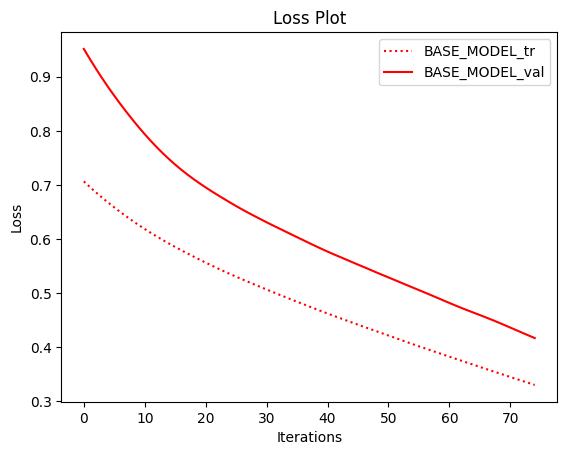

In [39]:
run_eval_helper(["BASE_MODEL"], models=[get_model(model_name=MODELS.BASE)])

## 4, 5, 6 - TECHNIQUES (BATCHES 1/8)
Running though batches the model improved. In batch 16, the val recall is low and the didn't converge, maybe overfitted by too many iterations. Batch 256 metrics are poor all around because overwhelmed by too much info fed at once. Batch 64 worked alot better, stats are decent but recall on val is a little low.
I will be using batch 64 in my final model.

NAME        |TR_ACC    |VAL_ACC   |TR_PREC   |VAL_PREC  |TR_REC    |VAL_REC   |Time(s)   
BATCH 16    |1.0       |0.98      |1.0       |1.0       |1.0       |0.83      |14.88     
BATCH 64    |0.96      |0.95      |0.8       |0.96      |1.0       |0.5       |10.69     
BATCH 256   |0.9       |0.9       |0.42      |0.9       |0.81      |0.5       |10.71     




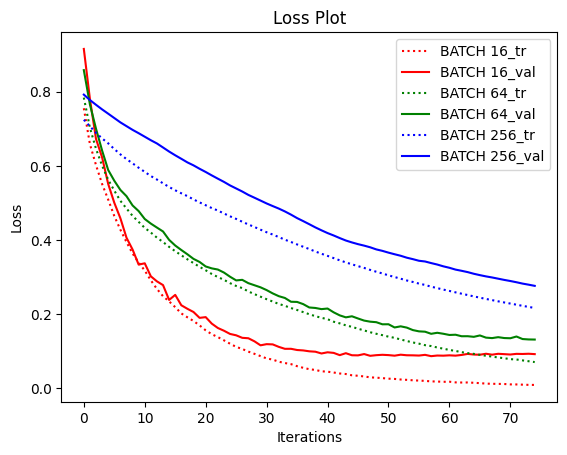

In [40]:
run_eval_helper(list(BATCH_CONFIGS.keys()), batch_sizes=list(BATCH_CONFIGS.values()))

## 4, 5, 6 - TECHNIQUES (DROPOUT 2/8)
Dropout is killing random neurons to avoid overfitting. All performed poorly and the plots are incomprehensible, because not enough data transfer. I think the model needs as much neurons as it can. Will not use this in final model.

NAME        |TR_ACC    |VAL_ACC   |TR_PREC   |VAL_PREC  |TR_REC    |VAL_REC   |Time(s)   
DROP 0.1    |0.89      |0.91      |1.0       |0.89      |0.62      |0.5       |9.68      
DROP 0.4    |0.84      |0.95      |0.4       |0.84      |0.19      |0.0       |8.7       
DROP 0.7    |0.72      |0.75      |0.12      |0.72      |0.25      |0.0       |8.66      




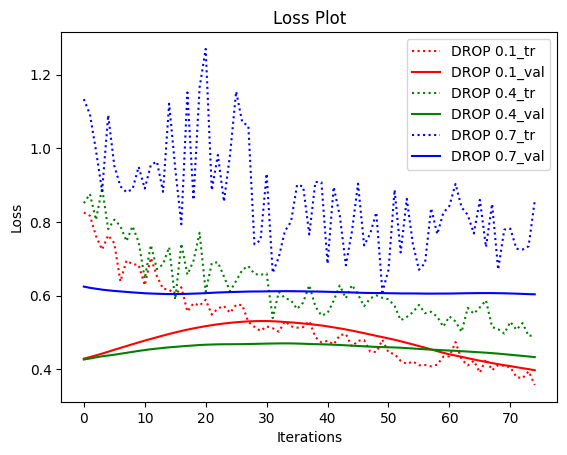

In [41]:
dropout_models = [get_model(model_name=MODELS.DROPOUT, config=val) for val in list(DROP_CONFIGS.values())]
run_eval_helper(list(DROP_CONFIGS.keys()), models=dropout_models)

## 4, 5, 6 - TECHNIQUES (BATCHE NORM 3/8)
Normalizes inputs at each hidden layer. Metrics are decent, but the losses didn't converge nicely, very jagged and validation is all over the place. I'll try it in the final model. Maybe early stop could benfit this model.

NAME        |TR_ACC    |VAL_ACC   |TR_PREC   |VAL_PREC  |TR_REC    |VAL_REC   |Time(s)   
BATCH_NORM  |0.99      |0.95      |0.89      |0.99      |1.0       |0.67      |16.91     




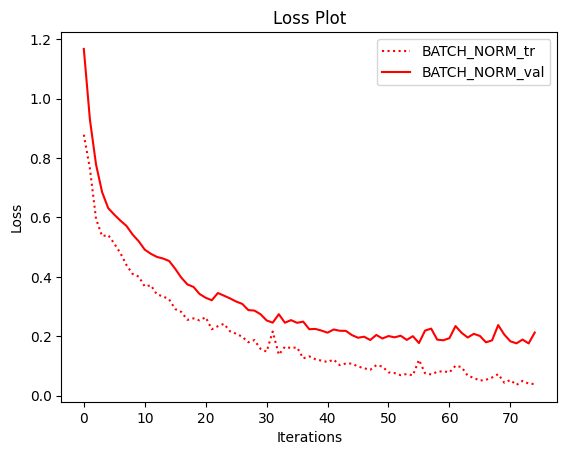

In [42]:
run_eval_helper(["BATCH_NORM"], models=[get_model(model_name=MODELS.BATCH_NORM)], batch_sizes=[16])

## 4, 5, 6 - TECHNIQUES (EARLY STOP 4/8)
Stops the model training when the val loss converges at a stable position. Important to pick the amount of wait to stop because loss could improve after you stop it. The precision and recall are poor, so I think it stopped early. However, I think faster models would benefit from this. Will add to final model.

NAME        |TR_ACC    |VAL_ACC   |TR_PREC   |VAL_PREC  |TR_REC    |VAL_REC   |Time(s)   
EARLY_STOP  |0.82      |0.82      |0.38      |0.82      |0.56      |0.33      |8.42      




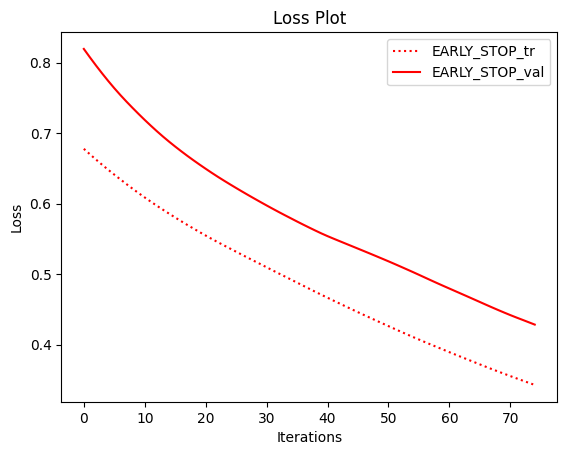

In [43]:
run_eval_helper(["EARLY_STOP"], early_stop=EARLY_STOP)

## 4, 5, 6 - TECHNIQUES (L1 REG 5/8)
Penalizes memorization using an absolute sum of numbers towards the loss. Seems to be poor for my situation, 0.001 rarely does anything and it did the best so I will not use it for my model.

NAME        |TR_ACC    |VAL_ACC   |TR_PREC   |VAL_PREC  |TR_REC    |VAL_REC   |Time(s)   
L1 0.001    |0.86      |0.86      |0.5       |0.86      |0.5       |0.5       |9.51      
L1 0.05     |0.81      |0.81      |0.31      |0.81      |0.31      |0.5       |9.38      
L1 0.1      |0.78      |0.75      |0.0       |0.78      |0.0       |0.0       |8.26      




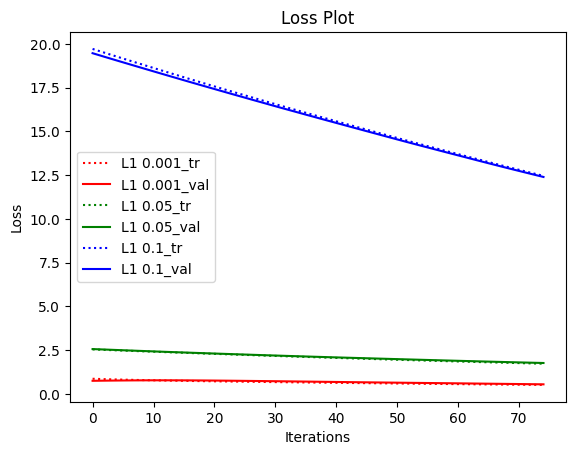

In [44]:
l1_models = [get_model(model_name=MODELS.L1_REG, config=val) for val in list(L1_CONFIGS.values())]
run_eval_helper(list(L1_CONFIGS.keys()), models=l1_models)

## 4, 5, 6 - TECHNIQUES (L2 REG 6/8)
Penalizes memorization using an squared sum of numbers towards the loss. Did poorly like L1 but loss values are better.

NAME        |TR_ACC    |VAL_ACC   |TR_PREC   |VAL_PREC  |TR_REC    |VAL_REC   |Time(s)   
L2 0.0001   |0.91      |0.9       |0.43      |0.91      |0.81      |0.5       |8.88      
L2 0.01     |0.87      |0.87      |0.57      |0.87      |0.62      |0.67      |9.11      
L2 0.1      |0.81      |0.78      |0.57      |0.81      |0.25      |0.17      |9.35      




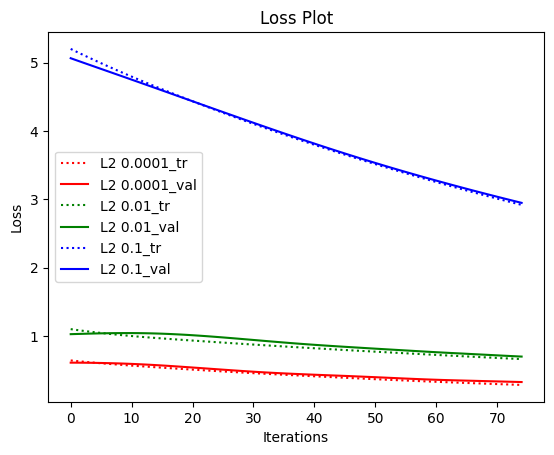

In [45]:
l2_models = [get_model(model_name=MODELS.L2_REG, config=val) for val in list(L2_CONFIGS.values())]
run_eval_helper(list(L2_CONFIGS.keys()), models=l2_models)

## 4, 5, 6 - TECHNIQUES (LR EXP 7/8)
Learning rate is the step the gradient runs towards the most optimal weights. Alot of overfitting after 30 iters. Early stop would benefit, but stats look decent with +0.001 performing well. Validation curves of 0.06 and 0.01 looks better than the other, will use for final model.


NAME        |TR_ACC    |VAL_ACC   |TR_PREC   |VAL_PREC  |TR_REC    |VAL_REC   |Time(s)   
LR 0.001    |0.85      |0.85      |1.0       |0.85      |0.12      |0.17      |8.64      
LR 0.006    |0.99      |0.94      |0.94      |0.99      |1.0       |0.67      |9.45      
LR 0.01     |1.0       |0.97      |1.0       |1.0       |1.0       |0.83      |9.39      
LR 0.06     |1.0       |0.97      |1.0       |1.0       |1.0       |1.0       |9.33      
LR 0.1      |1.0       |0.96      |1.0       |1.0       |1.0       |1.0       |7.93      




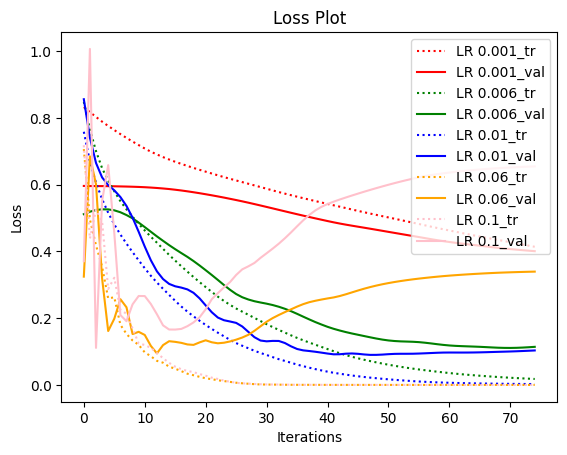

In [46]:
lr_optims = [get_optimizer(lr=val) for val in list(LR_CONFIGS.values())]
run_eval_helper(list(LR_CONFIGS.keys()), optims=lr_optims)

## 4, 5, 6 - TECHNIQUES (VARIOUS OPTIMIZERS 8/8)
There a several optimizers that have different strategies regarding getting to the optimium weight with scheduler, rates, and so on. Adam and RMSprop loss are way better than SGD but RMSprop metrics are pretty good compared to Adam.

NAME        |TR_ACC    |VAL_ACC   |TR_PREC   |VAL_PREC  |TR_REC    |VAL_REC   |Time(s)   
ADAM        |0.8       |0.83      |1.0       |0.8       |0.44      |0.33      |9.1       
RMSprop     |0.89      |0.87      |0.39      |0.89      |0.69      |0.5       |8.91      
SGD         |0.96      |0.95      |0.0       |0.96      |0.0       |0.0       |7.34      




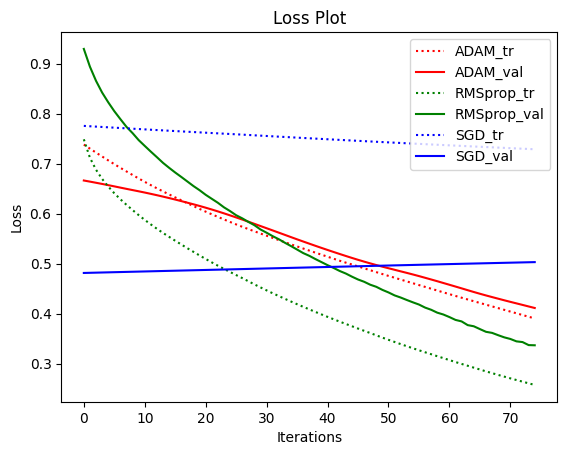

In [47]:
select_optims = [get_optimizer(optimizer_name=name) for name in list(OPTIMIZERS)]
run_eval_helper([optim.value for optim in OPTIMIZERS], optims=select_optims)

## 7 - FINAL MODEL
Used batch norm because that model had best consistent stats, so did RMSprop. Batch of 64 performed way better than others and I think early stop is always benefitial.

NAME        |TR_ACC    |VAL_ACC   |TR_PREC   |VAL_PREC  |TR_REC    |VAL_REC   |Time(s)   
FINAL       |0.99      |0.97      |0.84      |0.99      |1.0       |0.67      |6.14      


BASE_MODEL  |0.86      |0.87      |0.42      |0.86      |0.62      |0.5       |9.1       
None


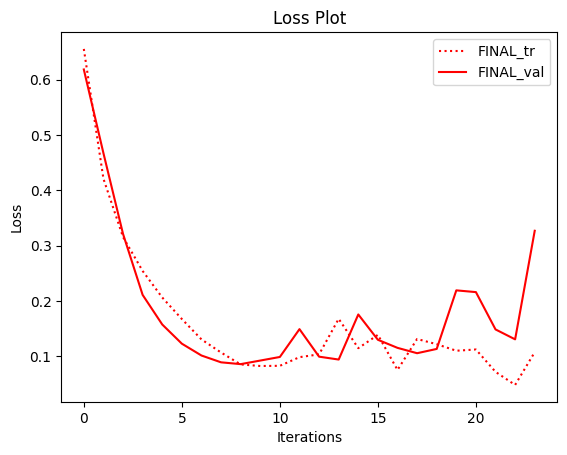

In [48]:
final_optim = get_optimizer(optimizer_name=OPTIMIZERS.ADAM, lr=0.01)
final_model = get_model(model_name=MODELS.BATCH_NORM)
run_eval_helper(["FINAL"], [final_model], [final_optim], [64], EARLY_STOP)
print(eval_pkgs[0].print())

## 8 - FINAL COMPARISON
Batch 64 was the best flow of input by far as it fed data methodically. SGD performed very poorly. Regularizations and dropout performed poorly, I think because my model wnts more complexities as the data isn't  abundant. Since it was a very imbalanced, models many suffered in precision but especially recall. However, Lr's or 0.01 and 0.01 had good stats all around and had good loss plots, even better than the final model, though the chart is saying 100% so maybe something went wrong cause perfect is not an optimal case. Time for all was around 5s - 10s nothing notable.

In [49]:
print(eval_pkgs[0].print_legend())
for pkg in eval_pkgs:
    pkg.print()

NAME        |TR_ACC    |VAL_ACC   |TR_PREC   |VAL_PREC  |TR_REC    |VAL_REC   |Time(s)   
None
BASE_MODEL  |0.86      |0.87      |0.42      |0.86      |0.62      |0.5       |9.1       
BATCH 16    |1.0       |0.98      |1.0       |1.0       |1.0       |0.83      |14.88     
BATCH 64    |0.96      |0.95      |0.8       |0.96      |1.0       |0.5       |10.69     
BATCH 256   |0.9       |0.9       |0.42      |0.9       |0.81      |0.5       |10.71     
DROP 0.1    |0.89      |0.91      |1.0       |0.89      |0.62      |0.5       |9.68      
DROP 0.4    |0.84      |0.95      |0.4       |0.84      |0.19      |0.0       |8.7       
DROP 0.7    |0.72      |0.75      |0.12      |0.72      |0.25      |0.0       |8.66      
BATCH_NORM  |0.99      |0.95      |0.89      |0.99      |1.0       |0.67      |16.91     
EARLY_STOP  |0.82      |0.82      |0.38      |0.82      |0.56      |0.33      |8.42      
L1 0.001    |0.86      |0.86      |0.5       |0.86      |0.5       |0.5       |9.51      
L1 0.